# Financial Network Engineering with Graph Neural Networks
Hybrid Deterministic-Learning Approach for Systemic Risk Analysis
Author: Samuel Montañez-Jacquez
For: MDPI Complexity Journal

This code extends the deterministic Flow Network Model with Graph Neural Networks to learn emergent patterns in financial contagion dynamics.

In [1]:
import torch

def format_pytorch_version(version):
  return version.split('+')[0]

TORCH_VERSION = torch.__version__
TORCH = format_pytorch_version(TORCH_VERSION)
CUDA = 'cu' + torch.version.cuda.replace('.', '')

# Dynamically install torch-geometric and its dependencies based on the installed PyTorch and CUDA versions
# This ensures compatibility with Colab's changing environment
!pip install torch-scatter -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-geometric

!pip install matplotlib seaborn pandas numpy scikit-learn

print("Installation complete!")

Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 125.3 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 109.8 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 70.0 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.6 MB/s eta 0:00:00
Installation complete!


In [3]:
# ============================================================================
# PART 2: FLOW NETWORK SIMULATOR
# ============================================================================

def flow_network_simulator(a_values, h_values, interbank_matrix,
                           cash_values, shock_magnitude=0.5):
    """
    Simple one-step loss simulator with an equity→external-debt waterfall.

    Pre-shock equity per bank i:
        e0_i = a_i + cash_i - interbank_i - h_i

    Shock:
        a'_i = a_i * (1 - shock_magnitude)

    Post-shock equity:
        e1_i = a'_i + cash_i - interbank_i - h_i

    Waterfall per bank i:
      * If e1_i >= 0:
            - Equity absorbs the shock: loss = max(0, e0_i - e1_i)
            - External debt is untouched.
      * If e1_i < 0 (default):
            - Equity is fully wiped (loss = max(0, e0_i)).
            - Residual shortfall hits external debt up to h_i
              (limited liability: creditors cannot lose more than h_i).

    Returns:
        - total_equity_loss
        - total_external_debt_loss
        - total_systemic_risk = E_loss + H_loss
        - num_failures
        - failure_vector (0/1 per bank)
        - initial_equity (pre-shock e0)
        - post_equity (post-shock e1)
    """
    n_banks = len(a_values)

    # 1) Totals from interbank matrix
    total_interbank_debt = interbank_matrix.sum(axis=1)  # row sums

    # 2) Pre- and post-shock equity
    pre_equity  = a_values + cash_values - total_interbank_debt - h_values
    a_shocked   = a_values * (1.0 - shock_magnitude)
    post_equity = a_shocked + cash_values - total_interbank_debt - h_values

    # 3) Per-bank equity and external-debt losses (simple waterfall)
    equity_loss_i   = np.zeros(n_banks)
    ext_debt_loss_i = np.zeros(n_banks)
    failures        = np.zeros(n_banks, dtype=int)

    for i in range(n_banks):
        if post_equity[i] >= 0:
            # Equity absorbs the shock; no default, no external-debt hit
            equity_loss_i[i] = max(0.0, pre_equity[i] - post_equity[i])
            ext_debt_loss_i[i] = 0.0
        else:
            # Bank defaults: equity is fully wiped, residual hits external debt
            failures[i] = 1
            # Equity loss capped at pre-equity (cannot lose more than you had)
            equity_loss_i[i] = max(0.0, pre_equity[i])
            residual = -post_equity[i]  # shortfall after equity is gone
            # External creditors bear up to h_i
            ext_debt_loss_i[i] = min(residual, h_values[i])

    total_equity_loss        = float(equity_loss_i.sum())
    total_external_debt_loss = float(ext_debt_loss_i.sum())
    total_systemic_risk      = total_equity_loss + total_external_debt_loss
    num_failures             = int(failures.sum())

    return {
        'equity_loss': total_equity_loss,
        'external_debt_loss': total_external_debt_loss,
        'total_systemic_risk': total_systemic_risk,
        'num_failures': num_failures,
        'failure_vector': failures,
        'initial_equity': pre_equity.copy(),
        'post_equity': post_equity.copy(),
    }

print("Flow network simulator defined")

# ============================================================================
# PART 3: GRAPH DATA GENERATION
# ============================================================================

def create_financial_graph(a_values, h_values, cash_values,
                           interbank_matrix, shock_magnitude, result):
    """Convert one flow-network scenario into a PyG graph."""
    n_banks = 4

    # Node features: [external assets, cash, external debt, interbank debt, initial equity]
    total_interbank_debt = interbank_matrix.sum(axis=1)
    initial_equity = a_values + cash_values - total_interbank_debt - h_values
    node_features = np.column_stack([
        a_values,
        cash_values,
        h_values,
        total_interbank_debt,
        initial_equity
    ])

    # Directed edges for all non-zero interbank exposures
    edge_index = []
    edge_attr = []
    for i in range(n_banks):
        for j in range(n_banks):
            if interbank_matrix[i, j] > 0:
                edge_index.append([i, j])
                edge_attr.append([interbank_matrix[i, j], shock_magnitude])

    x = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # Targets: [Equity Loss, External Debt Loss, Total SR, Num Failures]
    y = torch.tensor([
        result['equity_loss'],
        result['external_debt_loss'],
        result['total_systemic_risk'],
        result['num_failures']
    ], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)


def generate_training_dataset(n_scenarios_per_quarter=5000, quarters_data=None):
    """Generate a dataset of graph scenarios across crisis quarters."""
    print("="*80)
    print("GENERATING GRAPH DATASET FROM FLOW NETWORK SIMULATIONS")
    print("="*80)

    if quarters_data is None:
        # Stylized balance-sheet templates per quarter (can be replaced by real data)
        quarters_data = [
            {'a': np.array([900, 850, 920, 880]), 'h': np.array([600, 580, 620, 590])},  # Q4-2007
            {'a': np.array([850, 800, 870, 830]), 'h': np.array([610, 590, 630, 600])},  # Q1-2008
            {'a': np.array([800, 750, 820, 780]), 'h': np.array([620, 600, 640, 610])},  # Q2-2008
            {'a': np.array([650, 600, 670, 630]), 'h': np.array([640, 620, 660, 630])},  # Q3-2008
            {'a': np.array([700, 650, 720, 680]), 'h': np.array([630, 610, 650, 620])},  # Q4-2008
            {'a': np.array([720, 670, 740, 700]), 'h': np.array([620, 600, 640, 610])},  # Q1-2009
        ]

    all_graphs = []
    quarter_labels = ['Q4-2007', 'Q1-2008', 'Q2-2008',
                      'Q3-2008', 'Q4-2008', 'Q1-2009']

    for q_idx, quarter_data in enumerate(tqdm(quarters_data, desc="Processing quarters")):
        for scenario in range(n_scenarios_per_quarter):
            # External assets with random perturbation
            a_values = quarter_data['a'] + np.random.normal(0, 50, 4)
            a_values = np.maximum(a_values, 100.0)

            # External debt with random perturbation
            h_values = quarter_data['h'] + np.random.normal(0, 30, 4)
            h_values = np.maximum(h_values, 50.0)

            # Cash balances with mild noise
            cash_values = np.array([100, 100, 100, 100]) + np.random.normal(0, 10, 4)
            cash_values = np.maximum(cash_values, 20.0)

            # Random dense interbank matrix, normalized to a fixed row total (~200)
            interbank_matrix = np.random.uniform(30, 80, (4, 4))
            np.fill_diagonal(interbank_matrix, 0.0)
            row_sums = interbank_matrix.sum(axis=1)
            interbank_matrix = (interbank_matrix.T / row_sums * 200.0).T

            # Shock size
            shock_magnitude = np.random.uniform(0.1, 0.7)

            # New simulator uses cash_values explicitly
            result = flow_network_simulator(
                a_values,
                h_values,
                interbank_matrix,
                cash_values=cash_values,
                shock_magnitude=shock_magnitude
            )

            graph = create_financial_graph(
                a_values,
                h_values,
                cash_values,
                interbank_matrix,
                shock_magnitude,
                result
            )

            graph.quarter = q_idx
            graph.quarter_name = quarter_labels[q_idx]
            all_graphs.append(graph)

    print(f"\nGenerated {len(all_graphs)} graph scenarios")
    return all_graphs

print("Graph creation functions defined")

# ============================================================================
# FIXED GNN CLASS - Without Edge Features in Attention
# ============================================================================

class FinancialContagionGNN(nn.Module):
    """
    Multi-step GNN for systemic risk estimation.

    - Performs K rounds of message passing over the interbank network.
    - Input node_features are first projected into a hidden space.
    - Each step uses GATConv(hidden -> hidden) with a residual connection.
    - Then we pool to graph level and apply an MLP head that outputs:
        [Equity Loss, External Debt Loss, Total Systemic Risk, Num Failures]
    """

    def __init__(
        self,
        node_features: int = 5,
        hidden_channels: int = 64,
        num_heads: int = 4,
        num_steps: int = 3,   # K: number of contagion/message-passing rounds
        dropout: float = 0.2,
    ):
        super().__init__()

        self.hidden_channels = hidden_channels
        self.num_steps = num_steps
        self.dropout = nn.Dropout(dropout)

        # 1) Project raw node features to hidden space
        self.input_proj = nn.Linear(node_features, hidden_channels)

        # 2) K message-passing layers over the graph
        self.convs = nn.ModuleList([
            GATConv(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                heads=num_heads,
                concat=False,      # output: [N, hidden_channels]
                dropout=dropout,
            )
            for _ in range(num_steps)
        ])

        # 3) Graph-level MLP head: hidden -> 32 -> 16 -> 4
        self.fc1 = nn.Linear(hidden_channels, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 4)  # 4 outputs (targets)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # 1) Node feature projection
        x = self.input_proj(x)
        x = F.elu(x)

        # 2) K rounds of message passing (contagion)
        for conv in self.convs:
            x_res = x
            x = conv(x, edge_index)
            x = F.elu(x)
            x = self.dropout(x)
            x = x + x_res  # residual connection

        # 3) Pool nodes to graph representation
        x = global_mean_pool(x, batch)

        # 4) MLP head to predict 4 systemic-risk targets
        x = F.elu(self.dropout(self.fc1(x)))
        x = F.elu(self.fc2(x))
        out = self.fc3(x)

        return out

print("FIXED GNN class defined (output dimension = 4)")

# ============================================================================
# PART 5: TRAINING FUNCTIONS
# ============================================================================

def _prepare_target(out, target):
    """
    Ensure that target has the same shape as out.

    Handles common PyG batching cases:
    - out:    [batch_size, 4]
    - target: [batch_size * 4]  (concatenated along dim 0)
    - or single-graph batches where target: [4]
    """
    target = target.float()

    # Already matching
    if out.shape == target.shape:
        return target

    # Case 1: target is 1D (e.g. [batch_size * 4] or [4])
    if target.dim() == 1 and out.dim() == 2:
        # Same total number of elements → just reshape
        if target.numel() == out.numel():
            return target.view_as(out)

        # Single-graph case: out = [1, 4], target = [4]
        if target.numel() == out.shape[1] and out.shape[0] == 1:
            return target.unsqueeze(0)

    # Case 2: target is 2D but flat vs out
    if target.dim() == 2 and target.numel() == out.numel():
        return target.view_as(out)

    # If we get here, something unexpected is going on
    raise RuntimeError(
        f"Cannot reshape target to match out:\n"
        f"  out.shape={out.shape}, target.shape={target.shape}"
    )

def train_gnn(model, train_loader, optimizer, criterion, device, y_mean_dev, y_std_dev):
    """
    One training epoch with normalized targets.

    - out, target are in RAW scale
    - We normalize both using TRAIN-set mean/std on-device
    - Loss is computed in normalized space
    """
    model.train()
    total_loss = 0.0

    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        out = model(data)                 # [B, 4] raw
        target = _prepare_target(out, data.y)

        out_norm    = (out    - y_mean_dev) / y_std_dev
        target_norm = (target - y_mean_dev) / y_std_dev

        loss = criterion(out_norm, target_norm)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.num_graphs

    return total_loss / len(train_loader.dataset)


def evaluate_gnn(model, loader, criterion, device, y_mean_dev, y_std_dev):
    """
    Evaluation with normalized loss but RAW outputs returned.

    Returns:
      avg_loss (normalized MSE),
      preds_raw [N,4],
      trues_raw [N,4]
    """
    model.eval()
    total_loss = 0.0
    preds, trues = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)                 # [B, 4] raw
            target = _prepare_target(out, data.y)

            out_norm    = (out    - y_mean_dev) / y_std_dev
            target_norm = (target - y_mean_dev) / y_std_dev

            loss = criterion(out_norm, target_norm)
            total_loss += loss.item() * data.num_graphs

            preds.append(out.cpu())
            trues.append(target.cpu())

    preds = torch.cat(preds, dim=0)
    trues = torch.cat(trues, dim=0)
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, preds, trues

# ============================================================================
# PART 6: VISUALIZATION FUNCTIONS
# ============================================================================

def plot_training_curves(train_losses, val_losses, save_path='Training_Curves.png'):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, 'o-', linewidth=2, markersize=6,
            color=COLORS['primary'], label='Training Loss')
    ax.plot(epochs, val_losses, 's-', linewidth=2, markersize=6,
            color=COLORS['accent'], label='Validation Loss')
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Mean Squared Error', fontweight='bold')
    ax.set_title('GNN Training Progress', fontweight='bold', pad=15)
    ax.legend(frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
    plt.savefig(save_path.replace('.png', '.tiff'),
                dpi=600, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()

def plot_prediction_accuracy(predictions, targets, save_path='GNN_Prediction_Accuracy.png'):
    labels = ['Equity Loss (E)', 'External Debt Loss (H)',
              'Total Systemic Risk (E+H)', 'Number of Failures']
    fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=300)
    axes = axes.flatten()
    for i, (ax, label) in enumerate(zip(axes, labels)):
        ax.scatter(targets[:, i], predictions[:, i], alpha=0.4, s=20,
                   color=COLORS['primary'], edgecolors='white', linewidth=0.5)
        min_val = min(targets[:, i].min(), predictions[:, i].min())
        max_val = max(targets[:, i].max(), predictions[:, i].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
                label='Perfect Prediction', alpha=0.7)
        r2 = r2_score(targets[:, i], predictions[:, i])
        mae = mean_absolute_error(targets[:, i], predictions[:, i])
        textstr = f'$R^2 = {r2:.3f}$\nMAE = {mae:.2f}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
                verticalalignment='top', bbox=props)
        ax.set_xlabel('Flow Network (Ground Truth)', fontweight='bold')
        ax.set_ylabel('GNN Prediction', fontweight='bold')
        ax.set_title(label, fontweight='bold', pad=10)
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
    plt.savefig(save_path.replace('.png', '.tiff'),
                dpi=600, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()

def plot_metrics_comparison(metrics, save_path='GNN_Metrics_Comparison.png'):
    """
    Publication-style bar chart of R^2 scores per target.
    """
    labels = list(metrics.keys())
    r2_scores = [metrics[l]['R2'] for l in labels]

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    x = np.arange(len(labels))

    bars = ax.bar(
        x,
        r2_scores,
        width=0.6,
        color=COLORS['accent'],
        edgecolor='black',
        linewidth=1.5,
        alpha=0.8
    )

    # Y-axis limits: include negative values if present
    min_r2 = min(r2_scores)
    ymin = min(0.0, min_r2 - 0.1)
    ymin = max(ymin, -2.0)
    ax.set_ylim([ymin, 1.05])

    # Reference lines
    ax.axhline(0.0, color='black', linestyle='-', linewidth=1.0)
    ax.axhline(0.9, color='red', linestyle='--', linewidth=1.5,
               alpha=0.7, label='Excellence Threshold (0.9)')

    # Bar labels
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    offset = 0.03 * y_range

    for bar, score in zip(bars, r2_scores):
        if score >= 0:
            text_y = score + offset
            va = 'bottom'
        else:
            text_y = score - offset
            va = 'top'
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            text_y,
            f'{score:.3f}',
            ha='center',
            va=va,
            fontweight='bold'
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Equity\nLoss', 'External\nDebt Loss',
         'Total\nSystemic Risk', 'Bank\nFailures'],
        fontsize=10
    )

    ax.set_xlabel('Predicted Variable', fontweight='bold')
    ax.set_ylabel(r'$R^2$ Score', fontweight='bold')
    ax.set_title('GNN Prediction Accuracy by Output Variable',
                 fontweight='bold', pad=15)

    ax.legend()
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
    plt.savefig(save_path.replace('.png', '.tiff'),
                dpi=600, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()

def create_results_table(metrics):
    print("\n" + "="*80)
    print("GNN PERFORMANCE METRICS")
    print("="*80)
    df = pd.DataFrame(metrics).T
    df.index.name = 'Target Variable'
    print("\n" + df.round(4).to_string())
    df.to_csv('GNN_Performance_Metrics.csv')
    print("\nSaved: GNN_Performance_Metrics.csv")
    return df

print("Visualization functions defined")

print("\n" + "="*80)
print("ALL FUNCTIONS DEFINED SUCCESSFULLY")
print("="*80)
print("\nNow run the execution cells below to:")
print("1. Generate dataset")
print("2. Initialize model")
print("3. Train GNN")
print("4. Evaluate and visualize")

Flow network simulator defined
Graph creation functions defined
FIXED GNN class defined (output dimension = 4)
Visualization functions defined

ALL FUNCTIONS DEFINED SUCCESSFULLY

Now run the execution cells below to:
1. Generate dataset
2. Initialize model
3. Train GNN
4. Evaluate and visualize


In [2]:
# ============================================================================
# IMPORTS - RUN THIS FIRST!
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Publication settings
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

COLORS = {'primary': '#003366', 'secondary': '#2E7D32', 'accent': '#1976D2', 'warning': '#F57C00', 'error': '#D32F2F', 'neutral': '#757575'}

print("Imports loaded successfully!")

Using device: cuda
Imports loaded successfully!



[1/5] Generating Graph Dataset...
GENERATING GRAPH DATASET FROM FLOW NETWORK SIMULATIONS


Processing quarters: 100%|██████████| 6/6 [00:06<00:00,  1.07s/it]



Generated 30000 graph scenarios

Dataset split:
  - Training: 21250 scenarios
  - Validation: 3750 scenarios
  - Test: 5000 scenarios
Data loaders created!

Target normalization (TRAIN):
           Equity Loss | mean =    308.153 | std =    286.794
    External Debt Loss | mean =   1037.662 | std =    585.592
   Total Systemic Risk | mean =   1345.815 | std =    544.311
    Number of Failures | mean =      3.738 | std =      0.818

[2/5] Initializing GNN...
Model: FinancialContagionGNN
Parameters: 53,940
Device: cuda

Expected: approximately 47,140 parameters
Model initialized successfully!

[3/5] Training GNN...
Epoch [5/50] - Train Loss: 1.0842, Val Loss: 1.2542
Epoch [10/50] - Train Loss: 0.8385, Val Loss: 0.9422
Epoch [15/50] - Train Loss: 0.7851, Val Loss: 1.0624
Epoch [20/50] - Train Loss: 0.7826, Val Loss: 0.9595
Epoch [25/50] - Train Loss: 0.7665, Val Loss: 0.9322
Epoch [30/50] - Train Loss: 0.7597, Val Loss: 0.9199
Epoch [35/50] - Train Loss: 0.7566, Val Loss: 0.9151
Epoch [4

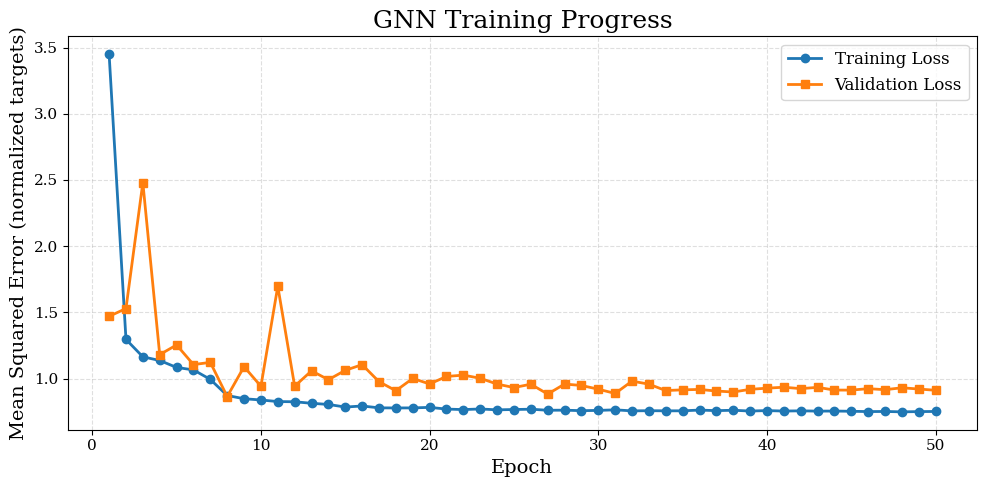

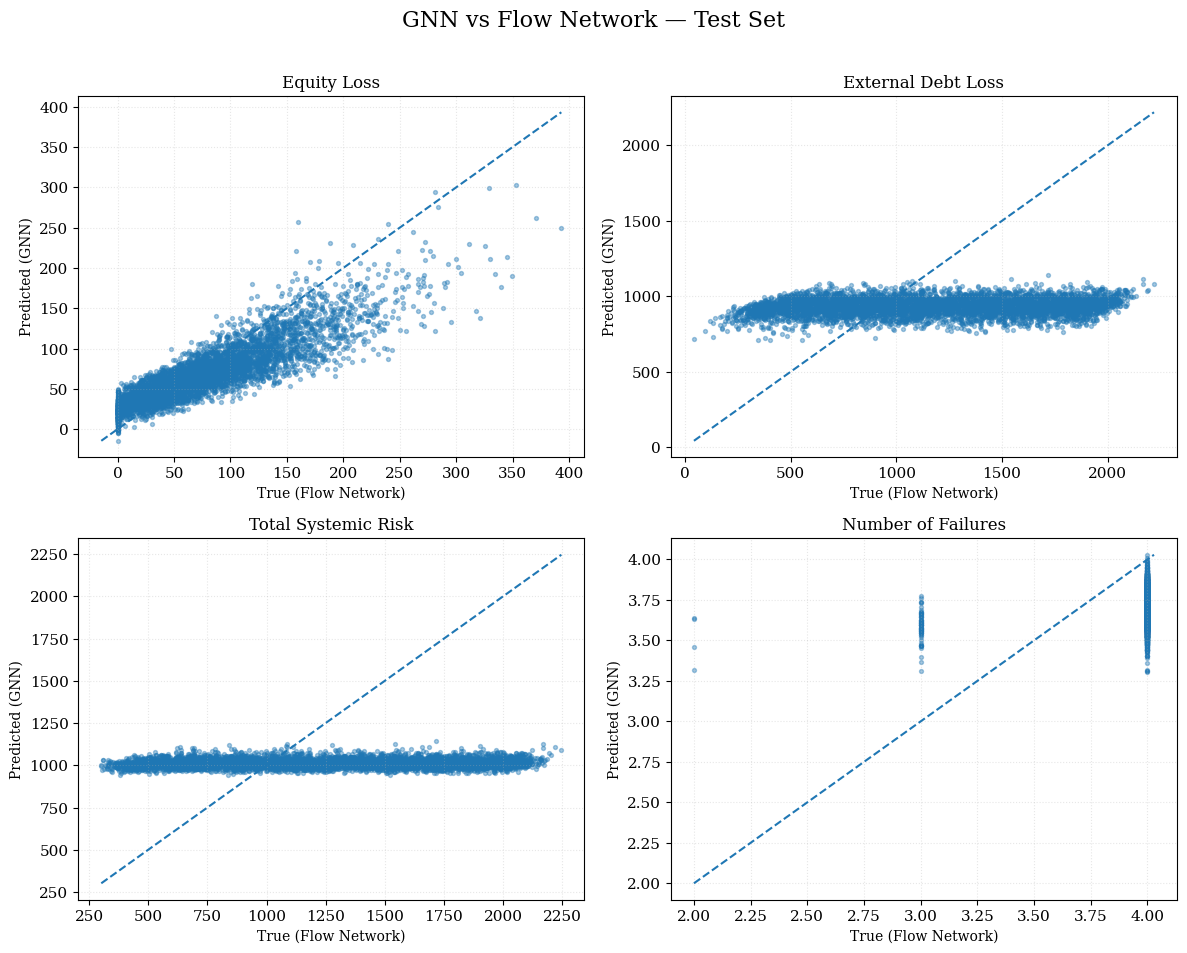


Saved GNN_Performance_Metrics.csv

Saved GNN_Performance_Metrics.csv
Saved: Fig_GNN_Metrics_Comparison.png


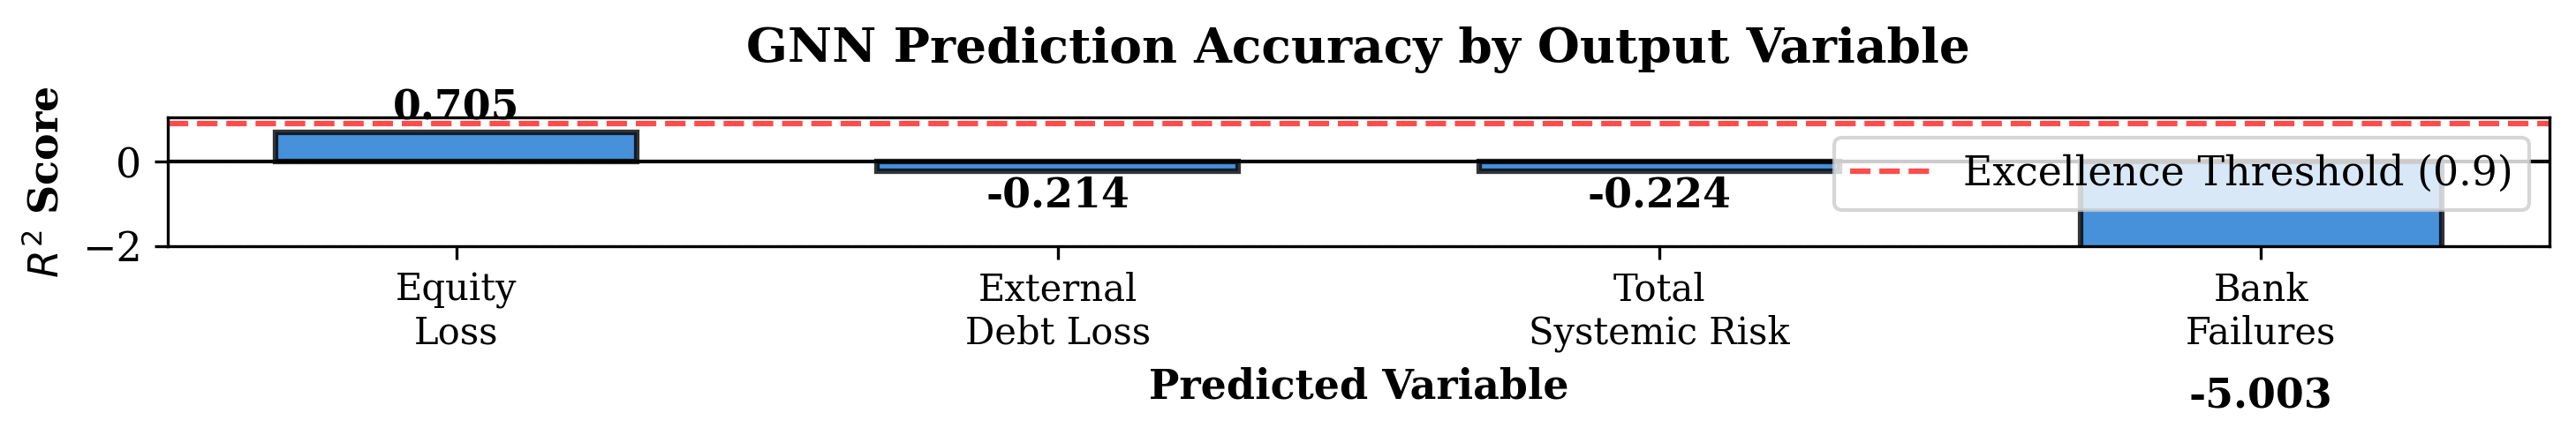


GNN ANALYSIS COMPLETE!

Key Findings (R² on raw scale):
  - GNN R2 for Total Systemic Risk: -0.224
  - GNN R2 for Equity Loss:        0.705
  - GNN R2 for External Debt Loss: -0.214
  - GNN R2 for Bank Failures:      -5.003

Generated Files:
  - Training_Curves.png / .tiff
  - GNN_Prediction_Accuracy.png / .tiff
  - GNN_Performance_Metrics.csv
  - best_gnn_model.pt



In [5]:
# ============================================================================
# EXECUTION CELLS - Run these AFTER all functions are defined
# ============================================================================

# CELL 1: Generate Dataset
# ============================================================================
print("\n[1/5] Generating Graph Dataset...")

all_graphs = generate_training_dataset(n_scenarios_per_quarter=5000)

train_graphs = [g for g in all_graphs if g.quarter < 5]
test_graphs  = [g for g in all_graphs if g.quarter == 5]
train_graphs, val_graphs = train_test_split(train_graphs, test_size=0.15, random_state=42)

print(f"\nDataset split:")
print(f"  - Training: {len(train_graphs)} scenarios")
print(f"  - Validation: {len(val_graphs)} scenarios")
print(f"  - Test: {len(test_graphs)} scenarios")

train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_graphs,  batch_size=64, shuffle=False)

print("Data loaders created!")

# --- Target normalization stats (TRAIN only) --------------------------------
with torch.no_grad():
    y_train = torch.stack([g.y for g in train_graphs], dim=0)   # [N_train, 4]
y_mean = y_train.mean(dim=0)                                   # [4]
y_std  = y_train.std(dim=0) + 1e-6                             # [4]

print("\nTarget normalization (TRAIN):")
for i, name in enumerate(["Equity Loss", "External Debt Loss", "Total Systemic Risk", "Number of Failures"]):
    print(f"  {name:>20s} | mean = {y_mean[i].item():10.3f} | std = {y_std[i].item():10.3f}")

y_mean_dev = y_mean.to(device)
y_std_dev  = y_std.to(device)

# ============================================================================
# CELL 2: Initialize Model
# ============================================================================
print("\n[2/5] Initializing GNN...")

model = FinancialContagionGNN(
    node_features=5,
    hidden_channels=64,
    num_heads=4,
    dropout=0.2
).to(device)

param_count = sum(p.numel() for p in model.parameters())
print(f"Model: {model.__class__.__name__}")
print(f"Parameters: {param_count:,}")
print(f"Device: {device}")

if param_count > 50000:
    print("\nWARNING: Parameter count is too high!")
    print("Expected: approximately 47,140 parameters")
else:
    print("\nParameter count looks good!")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss(reduction="mean")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor=0.5, patience=5)

print("Model initialized successfully!")

# ============================================================================
# CELL 3: Train Model (normalized targets)
# ============================================================================
print("\n[3/5] Training GNN...")

num_epochs    = 50
train_losses  = []
val_losses    = []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    # TRAIN
    train_loss = train_gnn(
        model, train_loader, optimizer, criterion,
        device, y_mean_dev, y_std_dev
    )
    train_losses.append(train_loss)

    # VALIDATION
    val_loss, _, _ = evaluate_gnn(
        model, val_loader, criterion,
        device, y_mean_dev, y_std_dev
    )
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_gnn_model.pt')

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print(f"\nTraining completed!")
print(f"Best validation loss (normalized MSE): {best_val_loss:.4f}")

model.load_state_dict(torch.load('best_gnn_model.pt'))

# ============================================================================
# [4/5] Evaluate on Test Set
# ============================================================================
print("\n[4/5] Evaluating on Test Set...")

test_loss, preds, trues = evaluate_gnn(
    model, test_loader, criterion,
    device, y_mean_dev, y_std_dev
)

print(f"Test Loss (MSE on normalized targets, averaged over 4 dims): {test_loss:.4f}")

# Convert to NumPy (RAW scale) for metrics & plots
preds_np = preds.numpy()
trues_np = trues.numpy()

# Per-target MSE / MAE (RAW scale)
mse_per_target = np.mean((preds_np - trues_np) ** 2, axis=0)
mae_per_target = np.mean(np.abs(preds_np - trues_np), axis=0)

target_names = [
    "Equity Loss",
    "External Debt Loss",
    "Total Systemic Risk",
    "Number of Failures",
]

print("\nPer-target metrics (Test Set, raw scale):")
for i, name in enumerate(target_names):
    print(f"  {name:>20s} | MSE: {mse_per_target[i]:12.4f} | MAE: {mae_per_target[i]:10.4f}")

# ============================================================================
# [5/5] Publication-style visuals
# ============================================================================

# --- 1) Training curves ---
fig, ax = plt.subplots(figsize=(10, 5))
epochs = np.arange(1, len(train_losses) + 1)

ax.plot(epochs, train_losses, marker='o', linewidth=2.0, label="Training Loss")
ax.plot(epochs, val_losses,   marker='s', linewidth=2.0, label="Validation Loss")

ax.set_title("GNN Training Progress", fontsize=18)
ax.set_xlabel("Epoch", fontsize=14)
ax.set_ylabel("Mean Squared Error (normalized targets)", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=12, loc='best')

plt.tight_layout()
plt.savefig("Training_Curves.png", dpi=300)
plt.savefig("Training_Curves.tiff", dpi=300)
plt.show()

# --- 2) Scatter: Flow-network (true) vs GNN (pred) for each target ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, name in enumerate(target_names):
    ax = axes[i]
    ax.scatter(trues_np[:, i], preds_np[:, i], s=8, alpha=0.4)
    min_v = min(trues_np[:, i].min(), preds_np[:, i].min())
    max_v = max(trues_np[:, i].max(), preds_np[:, i].max())
    ax.plot([min_v, max_v], [min_v, max_v], linestyle='--')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("True (Flow Network)", fontsize=10)
    ax.set_ylabel("Predicted (GNN)", fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.3)

plt.suptitle("GNN vs Flow Network — Test Set", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig("GNN_Prediction_Accuracy.png", dpi=300)
plt.savefig("GNN_Prediction_Accuracy.tiff", dpi=300)
plt.show()

# Optional: save metrics for the paper
metrics_df = pd.DataFrame({
    "Target": target_names,
    "MSE": mse_per_target,
    "MAE": mae_per_target,
})
metrics_df.to_csv("GNN_Performance_Metrics.csv", index=False)
print("\nSaved GNN_Performance_Metrics.csv")

metrics_df.to_csv("GNN_Performance_Metrics.csv", index=False)
print("\nSaved GNN_Performance_Metrics.csv")

# Define metrics before using it for plotting
from sklearn.metrics import r2_score

metrics = {}
for i, name in enumerate(target_names):
    r2 = r2_score(trues_np[:, i], preds_np[:, i])
    metrics[name] = {"R2": r2}

# NEW: Generate metrics comparison visual (R2 bar chart)
plot_metrics_comparison(metrics, save_path="Fig_GNN_Metrics_Comparison.png")

# =============================================================================
# Final Summary
# =============================================================================
print("\n" + "="*80)
print("GNN ANALYSIS COMPLETE!")
print("="*80)

print("\nKey Findings (R² on raw scale):")
print(f"  - GNN R2 for Total Systemic Risk: {metrics['Total Systemic Risk']['R2']:.3f}")
print(f"  - GNN R2 for Equity Loss:        {metrics['Equity Loss']['R2']:.3f}")
print(f"  - GNN R2 for External Debt Loss: {metrics['External Debt Loss']['R2']:.3f}")
print(f"  - GNN R2 for Bank Failures:      {metrics['Number of Failures']['R2']:.3f}")

print("\nGenerated Files:")
print("  - Training_Curves.png / .tiff")
print("  - GNN_Prediction_Accuracy.png / .tiff")
print("  - GNN_Performance_Metrics.csv")
print("  - best_gnn_model.pt")
print("="*80 + "\n")

In [ ]:
# ============================================================================
# IMPORTS - RUN THIS FIRST!
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Publication settings
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

COLORS = {'primary': '#003366', 'secondary': '#2E7D32', 'accent': '#1976D2', 'warning': '#F57C00', 'error': '#D32F2F', 'neutral': '#757575'}

print("Imports loaded successfully!")

In [ ]:
# ============================================================================
# PART 2: FLOW NETWORK SIMULATOR
# ============================================================================

def flow_network_simulator(a_values, h_values, interbank_matrix,
                           cash_values, shock_magnitude=0.5):
    """
    Simple one-step loss simulator with an equity→external-debt waterfall.

    Pre-shock equity per bank i:
        e0_i = a_i + cash_i - interbank_i - h_i

    Shock:
        a'_i = a_i * (1 - shock_magnitude)

    Post-shock equity:
        e1_i = a'_i + cash_i - interbank_i - h_i

    Waterfall per bank i:
      * If e1_i >= 0:
            - Equity absorbs the shock: loss = max(0, e0_i - e1_i)
            - External debt is untouched.
      * If e1_i < 0 (default):
            - Equity is fully wiped (loss = max(0, e0_i)).
            - Residual shortfall hits external debt up to h_i
              (limited liability: creditors cannot lose more than h_i).

    Returns:
        - total_equity_loss
        - total_external_debt_loss
        - total_systemic_risk = E_loss + H_loss
        - num_failures
        - failure_vector (0/1 per bank)
        - initial_equity (pre-shock e0)
        - post_equity (post-shock e1)
    """
    n_banks = len(a_values)

    # 1) Totals from interbank matrix
    total_interbank_debt = interbank_matrix.sum(axis=1)  # row sums

    # 2) Pre- and post-shock equity
    pre_equity  = a_values + cash_values - total_interbank_debt - h_values
    a_shocked   = a_values * (1.0 - shock_magnitude)
    post_equity = a_shocked + cash_values - total_interbank_debt - h_values

    # 3) Per-bank equity and external-debt losses (simple waterfall)
    equity_loss_i   = np.zeros(n_banks)
    ext_debt_loss_i = np.zeros(n_banks)
    failures        = np.zeros(n_banks, dtype=int)

    for i in range(n_banks):
        if post_equity[i] >= 0:
            # Equity absorbs the shock; no default, no external-debt hit
            equity_loss_i[i] = max(0.0, pre_equity[i] - post_equity[i])
            ext_debt_loss_i[i] = 0.0
        else:
            # Bank defaults: equity is fully wiped, residual hits external debt
            failures[i] = 1
            # Equity loss capped at pre-equity (cannot lose more than you had)
            equity_loss_i[i] = max(0.0, pre_equity[i])
            residual = -post_equity[i]  # shortfall after equity is gone
            # External creditors bear up to h_i
            ext_debt_loss_i[i] = min(residual, h_values[i])

    total_equity_loss        = float(equity_loss_i.sum())
    total_external_debt_loss = float(ext_debt_loss_i.sum())
    total_systemic_risk      = total_equity_loss + total_external_debt_loss
    num_failures             = int(failures.sum())

    return {
        'equity_loss': total_equity_loss,
        'external_debt_loss': total_external_debt_loss,
        'total_systemic_risk': total_systemic_risk,
        'num_failures': num_failures,
        'failure_vector': failures,
        'initial_equity': pre_equity.copy(),
        'post_equity': post_equity.copy(),
    }

print("Flow network simulator defined")

# ============================================================================
# PART 3: GRAPH DATA GENERATION
# ============================================================================

def create_financial_graph(a_values, h_values, cash_values,
                           interbank_matrix, shock_magnitude, result):
    """Convert one flow-network scenario into a PyG graph."""
    n_banks = 4

    # Node features: [external assets, cash, external debt, interbank debt, initial equity]
    total_interbank_debt = interbank_matrix.sum(axis=1)
    initial_equity = a_values + cash_values - total_interbank_debt - h_values
    node_features = np.column_stack([
        a_values,
        cash_values,
        h_values,
        total_interbank_debt,
        initial_equity
    ])

    # Directed edges for all non-zero interbank exposures
    edge_index = []
    edge_attr = []
    for i in range(n_banks):
        for j in range(n_banks):
            if interbank_matrix[i, j] > 0:
                edge_index.append([i, j])
                edge_attr.append([interbank_matrix[i, j], shock_magnitude])

    x = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # Targets: [Equity Loss, External Debt Loss, Total SR, Num Failures]
    y = torch.tensor([
        result['equity_loss'],
        result['external_debt_loss'],
        result['total_systemic_risk'],
        result['num_failures']
    ], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)


def generate_training_dataset(n_scenarios_per_quarter=5000, quarters_data=None):
    """Generate a dataset of graph scenarios across crisis quarters."""
    print("="*80)
    print("GENERATING GRAPH DATASET FROM FLOW NETWORK SIMULATIONS")
    print("="*80)

    if quarters_data is None:
        # Stylized balance-sheet templates per quarter (can be replaced by real data)
        quarters_data = [
            {'a': np.array([900, 850, 920, 880]), 'h': np.array([600, 580, 620, 590])},  # Q4-2007
            {'a': np.array([850, 800, 870, 830]), 'h': np.array([610, 590, 630, 600])},  # Q1-2008
            {'a': np.array([800, 750, 820, 780]), 'h': np.array([620, 600, 640, 610])},  # Q2-2008
            {'a': np.array([650, 600, 670, 630]), 'h': np.array([640, 620, 660, 630])},  # Q3-2008
            {'a': np.array([700, 650, 720, 680]), 'h': np.array([630, 610, 650, 620])},  # Q4-2008
            {'a': np.array([720, 670, 740, 700]), 'h': np.array([620, 600, 640, 610])},  # Q1-2009
        ]

    all_graphs = []
    quarter_labels = ['Q4-2007', 'Q1-2008', 'Q2-2008',
                      'Q3-2008', 'Q4-2008', 'Q1-2009']

    for q_idx, quarter_data in enumerate(tqdm(quarters_data, desc="Processing quarters")):
        for scenario in range(n_scenarios_per_quarter):
            # External assets with random perturbation
            a_values = quarter_data['a'] + np.random.normal(0, 50, 4)
            a_values = np.maximum(a_values, 100.0)

            # External debt with random perturbation
            h_values = quarter_data['h'] + np.random.normal(0, 30, 4)
            h_values = np.maximum(h_values, 50.0)

            # Cash balances with mild noise
            cash_values = np.array([100, 100, 100, 100]) + np.random.normal(0, 10, 4)
            cash_values = np.maximum(cash_values, 20.0)

            # Random dense interbank matrix, normalized to a fixed row total (~200)
            interbank_matrix = np.random.uniform(30, 80, (4, 4))
            np.fill_diagonal(interbank_matrix, 0.0)
            row_sums = interbank_matrix.sum(axis=1)
            interbank_matrix = (interbank_matrix.T / row_sums * 200.0).T

            # Shock size
            shock_magnitude = np.random.uniform(0.1, 0.7)

            # New simulator uses cash_values explicitly
            result = flow_network_simulator(
                a_values,
                h_values,
                interbank_matrix,
                cash_values=cash_values,
                shock_magnitude=shock_magnitude
            )

            graph = create_financial_graph(
                a_values,
                h_values,
                cash_values,
                interbank_matrix,
                shock_magnitude,
                result
            )

            graph.quarter = q_idx
            graph.quarter_name = quarter_labels[q_idx]
            all_graphs.append(graph)

    print(f"\nGenerated {len(all_graphs)} graph scenarios")
    return all_graphs

print("Graph creation functions defined")

# ============================================================================
# FIXED GNN CLASS - Without Edge Features in Attention
# ============================================================================

class FinancialContagionGNN(nn.Module):
    """
    Multi-step GNN for systemic risk estimation.

    - Performs K rounds of message passing over the interbank network.
    - Input node_features are first projected into a hidden space.
    - Each step uses GATConv(hidden -> hidden) with a residual connection.
    - Then we pool to graph level and apply an MLP head that outputs:
        [Equity Loss, External Debt Loss, Total Systemic Risk, Num Failures]
    """

    def __init__(
        self,
        node_features: int = 5,
        hidden_channels: int = 64,
        num_heads: int = 4,
        num_steps: int = 3,   # K: number of contagion/message-passing rounds
        dropout: float = 0.2,
    ):
        super().__init__()

        self.hidden_channels = hidden_channels
        self.num_steps = num_steps
        self.dropout = nn.Dropout(dropout)

        # 1) Project raw node features to hidden space
        self.input_proj = nn.Linear(node_features, hidden_channels)

        # 2) K message-passing layers over the graph
        self.convs = nn.ModuleList([
            GATConv(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                heads=num_heads,
                concat=False,      # output: [N, hidden_channels]
                dropout=dropout,
            )
            for _ in range(num_steps)
        ])

        # 3) Graph-level MLP head: hidden -> 32 -> 16 -> 4
        self.fc1 = nn.Linear(hidden_channels, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 4)  # 4 outputs (targets)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # 1) Node feature projection
        x = self.input_proj(x)
        x = F.elu(x)

        # 2) K rounds of message passing (contagion)
        for conv in self.convs:
            x_res = x
            x = conv(x, edge_index)
            x = F.elu(x)
            x = self.dropout(x)
            x = x + x_res  # residual connection

        # 3) Pool nodes to graph representation
        x = global_mean_pool(x, batch)

        # 4) MLP head to predict 4 systemic-risk targets
        x = F.elu(self.dropout(self.fc1(x)))
        x = F.elu(self.fc2(x))
        out = self.fc3(x)

        return out

print("FIXED GNN class defined (output dimension = 4)")

# ============================================================================
# PART 5: TRAINING FUNCTIONS
# ============================================================================

def _prepare_target(out, target):
    """
    Ensure that target has the same shape as out.

    Handles common PyG batching cases:
    - out:    [batch_size, 4]
    - target: [batch_size * 4]  (concatenated along dim 0)
    - or single-graph batches where target: [4]
    """
    target = target.float()

    # Already matching
    if out.shape == target.shape:
        return target

    # Case 1: target is 1D (e.g. [batch_size * 4] or [4])
    if target.dim() == 1 and out.dim() == 2:
        # Same total number of elements → just reshape
        if target.numel() == out.numel():
            return target.view_as(out)

        # Single-graph case: out = [1, 4], target = [4]
        if target.numel() == out.shape[1] and out.shape[0] == 1:
            return target.unsqueeze(0)

    # Case 2: target is 2D but flat vs out
    if target.dim() == 2 and target.numel() == out.numel():
        return target.view_as(out)

    # If we get here, something unexpected is going on
    raise RuntimeError(
        f"Cannot reshape target to match out:\n"
        f"  out.shape={out.shape}, target.shape={target.shape}"
    )

def train_gnn(model, train_loader, optimizer, criterion, device, y_mean_dev, y_std_dev):
    """
    One training epoch with normalized targets.

    - out, target are in RAW scale
    - We normalize both using TRAIN-set mean/std on-device
    - Loss is computed in normalized space
    """
    model.train()
    total_loss = 0.0

    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        out = model(data)                 # [B, 4] raw
        target = _prepare_target(out, data.y)

        out_norm    = (out    - y_mean_dev) / y_std_dev
        target_norm = (target - y_mean_dev) / y_std_dev

        loss = criterion(out_norm, target_norm)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.num_graphs

    return total_loss / len(train_loader.dataset)


def evaluate_gnn(model, loader, criterion, device, y_mean_dev, y_std_dev):
    """
    Evaluation with normalized loss but RAW outputs returned.

    Returns:
      avg_loss (normalized MSE),
      preds_raw [N,4],
      trues_raw [N,4]
    """
    model.eval()
    total_loss = 0.0
    preds, trues = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)                 # [B, 4] raw
            target = _prepare_target(out, data.y)

            out_norm    = (out    - y_mean_dev) / y_std_dev
            target_norm = (target - y_mean_dev) / y_std_dev

            loss = criterion(out_norm, target_norm)
            total_loss += loss.item() * data.num_graphs

            preds.append(out.cpu())
            trues.append(target.cpu())

    preds = torch.cat(preds, dim=0)
    trues = torch.cat(trues, dim=0)
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, preds, trues

# ============================================================================
# PART 6: VISUALIZATION FUNCTIONS
# ============================================================================

def plot_training_curves(train_losses, val_losses, save_path='Training_Curves.png'):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, 'o-', linewidth=2, markersize=6,
            color=COLORS['primary'], label='Training Loss')
    ax.plot(epochs, val_losses, 's-', linewidth=2, markersize=6,
            color=COLORS['accent'], label='Validation Loss')
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Mean Squared Error', fontweight='bold')
    ax.set_title('GNN Training Progress', fontweight='bold', pad=15)
    ax.legend(frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
    plt.savefig(save_path.replace('.png', '.tiff'),
                dpi=600, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()

def plot_prediction_accuracy(predictions, targets, save_path='GNN_Prediction_Accuracy.png'):
    labels = ['Equity Loss (E)', 'External Debt Loss (H)',
              'Total Systemic Risk (E+H)', 'Number of Failures']
    fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=300)
    axes = axes.flatten()
    for i, (ax, label) in enumerate(zip(axes, labels)):
        ax.scatter(targets[:, i], predictions[:, i], alpha=0.4, s=20,
                   color=COLORS['primary'], edgecolors='white', linewidth=0.5)
        min_val = min(targets[:, i].min(), predictions[:, i].min())
        max_val = max(targets[:, i].max(), predictions[:, i].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
                label='Perfect Prediction', alpha=0.7)
        r2 = r2_score(targets[:, i], predictions[:, i])
        mae = mean_absolute_error(targets[:, i], predictions[:, i])
        textstr = f'$R^2 = {r2:.3f}$\nMAE = {mae:.2f}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
                verticalalignment='top', bbox=props)
        ax.set_xlabel('Flow Network (Ground Truth)', fontweight='bold')
        ax.set_ylabel('GNN Prediction', fontweight='bold')
        ax.set_title(label, fontweight='bold', pad=10)
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
    plt.savefig(save_path.replace('.png', '.tiff'),
                dpi=600, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()

def plot_metrics_comparison(metrics, save_path='GNN_Metrics_Comparison.png'):
    """
    Publication-style bar chart of R^2 scores per target.
    """
    labels = list(metrics.keys())
    r2_scores = [metrics[l]['R2'] for l in labels]

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    x = np.arange(len(labels))

    bars = ax.bar(
        x,
        r2_scores,
        width=0.6,
        color=COLORS['accent'],
        edgecolor='black',
        linewidth=1.5,
        alpha=0.8
    )

    # Y-axis limits: include negative values if present
    min_r2 = min(r2_scores)
    ymin = min(0.0, min_r2 - 0.1)
    ymin = max(ymin, -2.0)
    ax.set_ylim([ymin, 1.05])

    # Reference lines
    ax.axhline(0.0, color='black', linestyle='-', linewidth=1.0)
    ax.axhline(0.9, color='red', linestyle='--', linewidth=1.5,
               alpha=0.7, label='Excellence Threshold (0.9)')

    # Bar labels
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    offset = 0.03 * y_range

    for bar, score in zip(bars, r2_scores):
        if score >= 0:
            text_y = score + offset
            va = 'bottom'
        else:
            text_y = score - offset
            va = 'top'
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            text_y,
            f'{score:.3f}',
            ha='center',
            va=va,
            fontweight='bold'
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Equity\nLoss', 'External\nDebt Loss',
         'Total\nSystemic Risk', 'Bank\nFailures'],
        fontsize=10
    )

    ax.set_xlabel('Predicted Variable', fontweight='bold')
    ax.set_ylabel(r'$R^2$ Score', fontweight='bold')
    ax.set_title('GNN Prediction Accuracy by Output Variable',
                 fontweight='bold', pad=15)

    ax.legend()
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
    plt.savefig(save_path.replace('.png', '.tiff'),
                dpi=600, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()

def create_results_table(metrics):
    print("\n" + "="*80)
    print("GNN PERFORMANCE METRICS")
    print("="*80)
    df = pd.DataFrame(metrics).T
    df.index.name = 'Target Variable'
    print("\n" + df.round(4).to_string())
    df.to_csv('GNN_Performance_Metrics.csv')
    print("\nSaved: GNN_Performance_Metrics.csv")
    return df

print("Visualization functions defined")

print("\n" + "="*80)
print("ALL FUNCTIONS DEFINED SUCCESSFULLY")
print("="*80)
print("\nNow run the execution cells below to:")
print("1. Generate dataset")
print("2. Initialize model")
print("3. Train GNN")
print("4. Evaluate and visualize")


In [ ]:
# ============================================================================
# EXECUTION CELLS - Run these AFTER all functions are defined
# ============================================================================

# CELL 1: Generate Dataset
# ============================================================================
print("\n[1/5] Generating Graph Dataset...")

all_graphs = generate_training_dataset(n_scenarios_per_quarter=5000)

train_graphs = [g for g in all_graphs if g.quarter < 5]
test_graphs  = [g for g in all_graphs if g.quarter == 5]
train_graphs, val_graphs = train_test_split(train_graphs, test_size=0.15, random_state=42)

print(f"\nDataset split:")
print(f"  - Training: {len(train_graphs)} scenarios")
print(f"  - Validation: {len(val_graphs)} scenarios")
print(f"  - Test: {len(test_graphs)} scenarios")

train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_graphs,  batch_size=64, shuffle=False)

print("Data loaders created!")

# --- Target normalization stats (TRAIN only) --------------------------------
with torch.no_grad():
    y_train = torch.stack([g.y for g in train_graphs], dim=0)   # [N_train, 4]
y_mean = y_train.mean(dim=0)                                   # [4]
y_std  = y_train.std(dim=0) + 1e-6                             # [4]

print("\nTarget normalization (TRAIN):")
for i, name in enumerate(["Equity Loss", "External Debt Loss", "Total Systemic Risk", "Number of Failures"]):
    print(f"  {name:>20s} | mean = {y_mean[i].item():10.3f} | std = {y_std[i].item():10.3f}")

y_mean_dev = y_mean.to(device)
y_std_dev  = y_std.to(device)

# ============================================================================
# CELL 2: Initialize Model
# ============================================================================
print("\n[2/5] Initializing GNN...")

model = FinancialContagionGNN(
    node_features=5,
    hidden_channels=64,
    num_heads=4,
    dropout=0.2
).to(device)

param_count = sum(p.numel() for p in model.parameters())
print(f"Model: {model.__class__.__name__}")
print(f"Parameters: {param_count:,}")
print(f"Device: {device}")

if param_count > 50000:
    print("\nWARNING: Parameter count is too high!")
    print("Expected: approximately 47,140 parameters")
else:
    print("\nParameter count looks good!")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss(reduction="mean")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor=0.5, patience=5)

print("Model initialized successfully!")

# ============================================================================
# CELL 3: Train Model (normalized targets)
# ============================================================================
print("\n[3/5] Training GNN...")

num_epochs    = 50
train_losses  = []
val_losses    = []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    # TRAIN
    train_loss = train_gnn(
        model, train_loader, optimizer, criterion,
        device, y_mean_dev, y_std_dev
    )
    train_losses.append(train_loss)

    # VALIDATION
    val_loss, _, _ = evaluate_gnn(
        model, val_loader, criterion,
        device, y_mean_dev, y_std_dev
    )
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_gnn_model.pt')

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print(f"\nTraining completed!")
print(f"Best validation loss (normalized MSE): {best_val_loss:.4f}")

model.load_state_dict(torch.load('best_gnn_model.pt'))

# ============================================================================
# [4/5] Evaluate on Test Set
# ============================================================================
print("\n[4/5] Evaluating on Test Set...")

test_loss, preds, trues = evaluate_gnn(
    model, test_loader, criterion,
    device, y_mean_dev, y_std_dev
)

print(f"Test Loss (MSE on normalized targets, averaged over 4 dims): {test_loss:.4f}")

# Convert to NumPy (RAW scale) for metrics & plots
preds_np = preds.numpy()
trues_np = trues.numpy()

# Per-target MSE / MAE (RAW scale)
mse_per_target = np.mean((preds_np - trues_np) ** 2, axis=0)
mae_per_target = np.mean(np.abs(preds_np - trues_np), axis=0)

target_names = [
    "Equity Loss",
    "External Debt Loss",
    "Total Systemic Risk",
    "Number of Failures",
]

print("\nPer-target metrics (Test Set, raw scale):")
for i, name in enumerate(target_names):
    print(f"  {name:>20s} | MSE: {mse_per_target[i]:12.4f} | MAE: {mae_per_target[i]:10.4f}")

# ============================================================================
# [5/5] Publication-style visuals
# ============================================================================

# --- 1) Training curves ---
fig, ax = plt.subplots(figsize=(10, 5))
epochs = np.arange(1, len(train_losses) + 1)

ax.plot(epochs, train_losses, marker='o', linewidth=2.0, label="Training Loss")
ax.plot(epochs, val_losses,   marker='s', linewidth=2.0, label="Validation Loss")

ax.set_title("GNN Training Progress", fontsize=18)
ax.set_xlabel("Epoch", fontsize=14)
ax.set_ylabel("Mean Squared Error (normalized targets)", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=12, loc='best')

plt.tight_layout()
plt.savefig("Training_Curves.png", dpi=300)
plt.savefig("Training_Curves.tiff", dpi=300)
plt.show()

# --- 2) Scatter: Flow-network (true) vs GNN (pred) for each target ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, name in enumerate(target_names):
    ax = axes[i]
    ax.scatter(trues_np[:, i], preds_np[:, i], s=8, alpha=0.4)
    min_v = min(trues_np[:, i].min(), preds_np[:, i].min())
    max_v = max(trues_np[:, i].max(), preds_np[:, i].max())
    ax.plot([min_v, max_v], [min_v, max_v], linestyle='--')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("True (Flow Network)", fontsize=10)
    ax.set_ylabel("Predicted (GNN)", fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.3)

plt.suptitle("GNN vs Flow Network — Test Set", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig("GNN_Prediction_Accuracy.png", dpi=300)
plt.savefig("GNN_Prediction_Accuracy.tiff", dpi=300)
plt.show()

# Optional: save metrics for the paper
metrics_df = pd.DataFrame({
    "Target": target_names,
    "MSE": mse_per_target,
    "MAE": mae_per_target,
})
metrics_df.to_csv("GNN_Performance_Metrics.csv", index=False)
print("\nSaved GNN_Performance_Metrics.csv")

metrics_df.to_csv("GNN_Performance_Metrics.csv", index=False)
print("\nSaved GNN_Performance_Metrics.csv")

# NEW: Generate metrics comparison visual (R2 bar chart)
plot_metrics_comparison(metrics, save_path="Fig_GNN_Metrics_Comparison.png")

# =============================================================================
# Final Summary
# =============================================================================
print("\n" + "="*80)
print("GNN ANALYSIS COMPLETE!")
print("="*80)

from sklearn.metrics import r2_score

metrics = {}
for i, name in enumerate(target_names):
    r2 = r2_score(trues_np[:, i], preds_np[:, i])
    metrics[name] = {"R2": r2}

print("\nKey Findings (R² on raw scale):")
print(f"  - GNN R2 for Total Systemic Risk: {metrics['Total Systemic Risk']['R2']:.3f}")
print(f"  - GNN R2 for Equity Loss:        {metrics['Equity Loss']['R2']:.3f}")
print(f"  - GNN R2 for External Debt Loss: {metrics['External Debt Loss']['R2']:.3f}")
print(f"  - GNN R2 for Bank Failures:      {metrics['Number of Failures']['R2']:.3f}")

print("\nGenerated Files:")
print("  - Training_Curves.png / .tiff")
print("  - GNN_Prediction_Accuracy.png / .tiff")
print("  - GNN_Performance_Metrics.csv")
print("  - best_gnn_model.pt")
print("="*80 + "\n")
